  # Trabalho Computacional 3 - Reconhecimento de Padrões



  ## Classificadores Gaussianos, DMP e Análise de Componentes Principais (PCA)



  **Aluno:** Lucas José Lemos Braz



  **Disciplina:** Reconhecimento de Padrões (Pós-Graduação)

  ### 1. Configurações e Importações



  Importação das bibliotecas científicas e configuração do ambiente de visualização.

In [1]:
import sys
import os
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas do Scikit-Learn para validação e métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Adicionando o diretório raiz ao path para importar os modelos customizados
sys.path.append(os.path.abspath("../../.."))

from classificao_padroes.models_trabalho3 import (
    analizar_invertibilidade,
    PCA,
    ClassificadorDMP,
    ClassificadorQuadraticoGaussiano
)

# Configurações de plotagem
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

2026-02-24 19:40:56.190 | INFO     | classificao_padroes.config:<module>:11 - PROJ_ROOT path is: /home/apo-pc/Documents/Github/Trabalhos_Rec_Padroes


  ### 2. Carregamento e Pré-processamento dos Dados

  O dataset *Wall-Following Robot* possui 24 sensores de ultrassom dispostos circularmente. 


Dataset Carregado: (5456, 24)
Classes: ['Move-Forward' 'Sharp-Right-Turn' 'Slight-Left-Turn' 'Slight-Right-Turn']


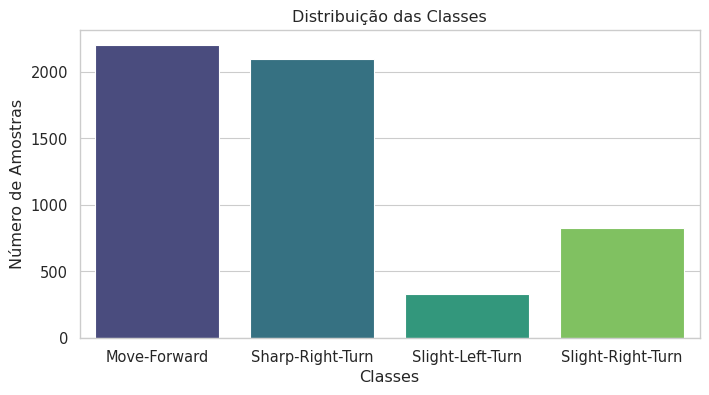

In [2]:
# Caminhos e carregamento
data_path_24 = "../../data/interin/wall+following+robot+navigation+data/sensor_readings_24.data"
col_names_24 = [f"US{i + 1}" for i in range(24)] + ["Class"]

data_df = pd.read_csv(data_path_24, names=col_names_24)

# Separação de Atributos e Classes
X_raw = data_df.drop("Class", axis=1).values
y_labels = data_df["Class"].values

# Codificação das classes (String -> Inteiro) para facilitar métricas
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
classes_nomes = le.classes_

X_scaled = X_raw  # Mantendo os dados originais para análise de invertibilidade e PCA

print(f"Dataset Carregado: {X_scaled.shape}")
print(f"Classes: {classes_nomes}")

# Verificação de Balanceamento
plt.figure(figsize=(8, 4))
sns.countplot(x=y_labels, palette='viridis', order=classes_nomes)
plt.title("Distribuição das Classes")
plt.xlabel("Classes")
plt.ylabel("Número de Amostras")
plt.show()



### 2.1 Analise dos dados das classes.

In [3]:
data_df.head(5)

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [4]:
# Construir um describe por classe para entender a distribuição dos atributos, usando For
for class_name in classes_nomes:
    print(f"\n--- Estatísticas para a Classe: {class_name} ---")
    display(data_df[data_df["Class"] == class_name].describe())


--- Estatísticas para a Classe: Move-Forward ---


,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000,2205.000000,2205.000000,2205.000000
mean,1.329706,2.269341,2.309382,2.683341,2.749585,2.752687,3.563091,2.498399,3.438539,2.905246,...,3.131303,1.200475,0.859291,0.860432,1.087659,1.070128,0.90283,1.698861,1.323893,1.270595
std,0.768690,1.475641,1.162698,1.308004,1.259571,1.231786,1.425589,1.062774,1.322182,1.244740,...,1.756047,1.130035,0.634465,0.774543,1.193669,1.101833,0.52750,1.539061,1.124892,0.850228
min,0.420000,0.437000,0.470000,0.833000,1.251000,1.268000,1.285000,0.966000,0.966000,0.917000,...,0.902000,0.457000,0.487000,0.495000,0.496000,0.495000,0.40700,0.384000,0.374000,0.384000
25%,0.821000,1.197000,1.555000,1.673000,1.661000,1.712000,2.043000,1.618000,2.451000,1.734000,...,1.330000,0.667000,0.612000,0.591000,0.601000,0.613000,0.62400,0.751000,0.751000,0.799000
50%,1.131000,1.745000,1.895000,2.147000,2.663000,2.546000,3.266000,2.075000,3.019000,2.804000,...,3.438000,0.762000,0.712000,0.675000,0.700000,0.716000,0.79000,0.948000,0.950000,1.064000
75%,1.608000,2.614000,2.490000,3.094000,3.158000,3.239000,5.000000,3.136000,5.000000,3.545000,...,5.000000,1.184000,0.854000,0.763000,0.809000,0.861000,0.99700,1.705000,1.237000,1.481000
max,5.000000,5.000000,5.000000,5.009000,5.000000,5.000000,5.008000,5.087000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000



--- Estatísticas para a Classe: Sharp-Right-Turn ---


,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,...,2097.00000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000,2097.000000
mean,1.594739,2.413119,2.583308,2.899262,3.173251,3.032242,3.197056,2.676467,3.022066,2.830513,...,1.15295,1.016471,0.862659,0.804617,0.956900,1.035887,1.158838,1.953623,1.873215,1.927893
std,0.921175,1.373160,1.250933,1.357074,1.403597,1.267280,1.354168,1.221067,1.440840,1.460877,...,1.09930,0.903615,0.717177,0.641031,0.983881,1.123053,1.175498,1.742869,1.583104,1.463700
min,0.410000,0.449000,0.492000,1.133000,1.120000,1.114000,1.129000,0.859000,0.836000,0.810000,...,0.49500,0.424000,0.373000,0.354000,0.371000,0.379000,0.380000,0.371000,0.372000,0.390000
25%,0.994000,1.378000,1.436000,1.575000,1.836000,1.864000,1.876000,1.547000,1.583000,1.552000,...,0.78300,0.678000,0.532000,0.507000,0.520000,0.544000,0.574000,0.752000,0.780000,0.893000
50%,1.358000,2.136000,2.435000,2.624000,2.850000,3.164000,3.208000,2.672000,2.789000,2.733000,...,0.82500,0.800000,0.777000,0.746000,0.742000,0.717000,0.768000,1.046000,1.244000,1.367000
75%,2.064000,2.748000,2.883000,4.231000,5.000000,4.064000,5.000000,3.258000,5.000000,4.956000,...,0.89400,0.913000,0.882000,0.871000,0.871000,0.851000,1.001000,3.682000,2.595000,2.528000
max,5.000000,5.025000,5.026000,5.000000,5.000000,5.005000,5.006000,5.000000,5.000000,5.022000,...,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000



--- Estatísticas para a Classe: Slight-Left-Turn ---


,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,328.000000,328.000000,328.00000,328.000000,328.000000,328.00000,328.000000,328.000000,328.000000,328.000000,...,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000
mean,2.126774,2.385284,2.28429,2.246930,2.115549,1.93993,2.002198,1.741244,1.790165,1.747564,...,2.189409,1.637159,2.061046,2.034951,2.643311,2.731229,1.465506,2.334777,2.343293,2.381933
std,0.366142,0.746258,0.67518,0.784806,0.751921,0.51432,0.789514,0.511946,0.469200,0.372319,...,1.401371,0.880188,1.395495,1.301159,1.352366,1.339673,0.872834,1.038717,0.784462,0.838451
min,0.583000,1.632000,1.61100,1.174000,1.125000,1.11400,1.122000,1.141000,1.089000,0.990000,...,0.907000,0.626000,0.882000,0.902000,0.906000,0.903000,0.467000,0.507000,0.519000,0.649000
25%,1.953750,2.040250,2.00575,1.996750,1.938750,1.71300,1.554750,1.407750,1.446750,1.502000,...,1.241500,1.258000,1.342750,1.383750,1.440000,1.941750,0.672500,1.914750,1.926500,1.919000
50%,2.108000,2.182000,2.13650,2.060000,1.997000,1.97950,1.992000,1.674500,1.669000,1.640000,...,1.602000,1.414000,1.406500,1.419000,2.347500,2.265000,1.031000,2.111500,2.125500,2.111500
75%,2.270000,2.340250,2.26450,2.213250,2.087250,2.01725,2.072000,1.985250,2.092500,1.904250,...,2.324000,1.602250,1.783000,2.359500,2.787500,3.142250,2.292250,2.361500,2.403250,2.396000
max,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,3.074000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000



--- Estatísticas para a Classe: Slight-Right-Turn ---


,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,...,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000,826.000000
mean,1.277715,2.239427,2.812645,3.055930,3.306074,3.293007,3.711998,2.624402,3.083493,3.073419,...,2.414415,1.505016,1.235794,0.864954,0.606701,0.538346,0.776472,1.322533,1.051345,1.194446
std,0.416212,1.510968,1.513559,1.262507,1.324366,1.419562,1.358294,0.973394,1.069393,1.073911,...,1.490041,1.390014,1.452865,1.172263,0.663969,0.271697,0.653889,1.197551,0.367486,0.361866
min,0.400000,0.438000,0.520000,1.374000,1.386000,1.407000,1.427000,1.448000,1.631000,1.553000,...,0.901000,0.451000,0.416000,0.386000,0.340000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,1.083000,1.352250,1.558250,1.930000,1.950250,1.884000,2.234250,1.879250,2.446750,2.369000,...,1.422250,0.726000,0.502000,0.470000,0.457000,0.469000,0.493000,0.580000,0.859000,1.053000
50%,1.338000,1.521000,1.998000,2.688000,2.953000,2.918000,3.270000,2.144000,2.672000,2.618000,...,1.747500,0.816000,0.613000,0.487000,0.478000,0.487000,0.524000,1.010000,1.067000,1.217500
75%,1.496750,2.390750,5.000000,4.210750,4.392500,5.000000,5.000000,3.210000,3.877750,3.845000,...,3.109000,1.680500,0.773000,0.565750,0.491000,0.521000,0.803000,1.469750,1.188750,1.415750
max,5.000000,5.021000,5.029000,5.017000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


A análise exploratória revela que os dados apresentam comportamento consistente entre as classes. Observa-se que todas as features possuem valor máximo de 5 para todas as classes, indicando uma escala comum de medição. 

Embora seja possível notar variações nas médias e medianas entre as diferentes classes, essas diferenças não são expressivas o suficiente para caracterizar um problema de magnitude. Ainda assim, como estratégia de precaução e para garantir melhor convergência dos algoritmos de aprendizado, opta-se por aplicar uma normalização aos dados, mesmo que estes já compartilhem a mesma ordem de grandeza.

  ### 3. Funções Auxiliares de Avaliação

  Como exigido no trabalho, não avaliamos o modelo em apenas uma rodada. Esta função executa **Nr=100 rodadas** de Monte Carlo (divisões aleatórias de treino/teste) para gerar estatísticas (Média e Desvio Padrão).

In [5]:
def executar_experimento_monte_carlo(X, y, classificador_class, params={}, n_runs=20, test_size=0.3, q_pca=None):
    """
    Executa N rodadas de treino e teste e coleta métricas globais e por classe.
    """
    print(f"Iniciando {n_runs} rodadas para {classificador_class.__name__}...")

    global_accuracies = []
    class_accuracies = {c: [] for c in np.unique(y)}
    times_train = []
    times_test = []

    for i in range(n_runs):
        # Divisão aleatória
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        if q_pca is not None:
            pca = PCA(n_componentes=q_pca)
            pca.fit(X_train)
            X_train = pca.transform(X_train)
            X_test = pca.transform(X_test)

        # Instanciação e Treino
        clf = classificador_class(**params)

        start_train = time.time()
        clf.fit(X_train, y_train)
        times_train.append(time.time() - start_train)

        # Teste
        start_test = time.time()
        y_pred = clf.predict(X_test)
        times_test.append(time.time() - start_test)

        # Métricas Globais
        global_accuracies.append(accuracy_score(y_test, y_pred))

        # Métricas por Classe (Recall/Acurácia por classe)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        for cls_label in np.unique(y):
            # O report usa strings dos labels se y for string, ou str(int) se y for int
            cls_key = str(cls_label)
            if cls_key in report:
                class_accuracies[cls_label].append(report[cls_key]['recall'])
            else:
                class_accuracies[cls_label].append(0.0)

    # Compilação dos Resultados
    results = {
        'Modelo': classificador_class.__name__,
        'Global_Mean': np.mean(global_accuracies),
        'Global_Std': np.std(global_accuracies),
        'Time_Train_Mean': np.mean(times_train),
        'Time_Train_STD': np.std(times_train),
        'Time_Test_Mean': np.mean(times_test),
        'Time_Test_STD': np.std(times_test)
    }

    # Adiciona média e desvio por classe
    for cls_label in np.unique(y):
        results[f'Class_{cls_label}_Mean'] = np.mean(class_accuracies[cls_label])
        results[f'Class_{cls_label}_Std'] = np.std(class_accuracies[cls_label])

    return results, global_accuracies


def formatar_tabela_latex(df_results, class_names):
    """Gera uma visualização amigável similar à tabela solicitada no PDF."""
    display_df = pd.DataFrame()
    display_df['Classificador'] = df_results['Modelo']

    # Formata Global
    display_df['Global'] = df_results.apply(lambda row: f"{row['Global_Mean']:.4f} ± {row['Global_Std']:.4f}", axis=1)

    # Formata por Classe
    for i, name in enumerate(class_names):
        display_df[f'{name}'] = df_results.apply(
            lambda row: f"{row[f'Class_{i}_Mean']:.4f} ± {row[f'Class_{i}_Std']:.4f}", axis=1
        )

    return display_df

  ---



  ## QUESTÃO 1: Análise sem PCA (Espaço Original 24D)







  ### 1.1 e 1.2: Análise de Invertibilidade



  Verifica-se se as matrizes de covariância são bem condicionadas para aplicação do CQG.

In [ ]:
# A função analisar_invertibilidade deve ser capaz de lidar com DataFrame ou Array
# Criando DF temporário apenas para essa função, se necessário
analizar_invertibilidade(data_df, "Original 24 Sensores")

# TODO: Está avaliando o condicionamento dos dados e não da matriz de convariancia.


Análise de Invertibilidade: Original 24 Sensores
Global -> Posto: 24, Cond: 2.05e+01, RCond: 4.87e-02
Classe Move-Forward -> Posto: 24, Cond: 5.35e+01, RCond: 1.87e-02
Classe Sharp-Right-Turn -> Posto: 24, Cond: 3.13e+01, RCond: 3.20e-02
Classe Slight-Left-Turn -> Posto: 24, Cond: 1.73e+02, RCond: 5.77e-03
Classe Slight-Right-Turn -> Posto: 24, Cond: 1.96e+02, RCond: 5.10e-03
--------------------------------------------------


Os resultados obtidos revelam que todas as classes apresentam matrizes de covariância bem condicionadas, com números de condição adequados e determinantes estritamente positivos. Isso indica que as matrizes são invertíveis e estáveis, garantindo que não haverá problemas de singularidade ou instabilidade numérica durante o processo de classificação.

A ausência de multicolinearidade severa entre os 24 sensores de ultrassom sugere que cada sensor fornece informação complementar ao sistema. Este comportamento favorável pode ser atribuído à disposição circular dos sensores, que capturam perspectivas distintas do ambiente de navegação do robô. Consequentemente, a aplicação direta do CQG no espaço original 24D é matematicamente viável e numericamente segura, sem necessidade de técnicas de regularização adicionais para estabilizar as inversões matriciais.

  ### 1.3: Experimento Comparativo (DMP vs CQG)



  Execução de 100 rodadas para preenchimento da tabela de desempenho.







  *Nota:* Para o DMP, definimos `k_max` baseado na heurística $\sqrt{N_{min}} \cdot 2$, para evitar overfitting (transformar o DMP em 1-NN).

In [7]:
# Configuração do DMP
N_min = data_df["Class"].value_counts().min()
k_max_heuristic = int(np.sqrt(N_min) * 2)  # Multiplicamos por 2 para permitir um pouco mais de flexibilidade, mas ainda evitar overfitting extremo
print(f"Heurística para DMP: k_max definido como {k_max_heuristic} (aprox sqrt({N_min}) * 2)")

# Parâmetros dos Modelos
params_dmp = {'k_min': 2, 'k_max': k_max_heuristic, 'n_runs': 20}  # n_runs interno do k-means
params_cqg = {}  # CQG padrão

# Execução (Pode levar alguns minutos devido às 100 rodadas)
res_dmp, acc_dmp = executar_experimento_monte_carlo(X_scaled, y_encoded, ClassificadorDMP, params_dmp, n_runs=100)
res_cqg, acc_cqg = executar_experimento_monte_carlo(X_scaled, y_encoded, ClassificadorQuadraticoGaussiano, params_cqg, n_runs=100)


Heurística para DMP: k_max definido como 36 (aprox sqrt(328) * 2)
Iniciando 100 rodadas para ClassificadorDMP...
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=34, CH=2, Dunn=18, Sil=34, I=2, BH=36] -> Frequências: [k=34(2x), k=2(2x), k=18(1x), k=36(1x)] -> K ótimo: 34
  Classe 1: Votos [DB=33, CH=2, Dunn=36, Sil=36, I=3, BH=36] -> Frequências: [k=36(3x), k=33(1x), k=2(1x), k=3(1x)] -> K ótimo: 36
  Classe 2: Votos [DB=35, CH=2, Dunn=12, Sil=32, I=2, BH=36] -> Frequências: [k=2(2x), k=35(1x), k=12(1x), k=32(1x), k=36(1x)] -> K ótimo: 2
  Classe 3: Votos [DB=29, CH=3, Dunn=13, Sil=29, I=2, BH=36] -> Frequências: [k=29(2x), k=3(1x), k=13(1x), k=2(1x), k=36(1x)] -> K ótimo: 29
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=24, CH=2, Dunn=9, Sil=36, I=3, BH=36] -> Frequências: [k=36(2x), k=24(1x), k=2(1x), k=9(1x), k=3(1x)] -> K ótimo: 36
  Classe 1: Votos [DB=31, CH=2, Dunn=35, Sil=36, I=3, BH=36] -> Frequências: [k=36(2x), k=31(1x), k=2(1


--- Tabela de Resultados (Questão 1.3) ---


,Classificador,Global,Move-Forward,Sharp-Right-Turn,Slight-Left-Turn,Slight-Right-Turn
0,ClassificadorQuadraticoGaussiano,0.6814 ± 0.0114,0.6316 ± 0.0167,0.6265 ± 0.0198,0.8867 ± 0.0300,0.8722 ± 0.0216
1,ClassificadorDMP,0.7220 ± 0.0640,0.7151 ± 0.1813,0.8091 ± 0.0847,0.8458 ± 0.1308,0.4729 ± 0.3707


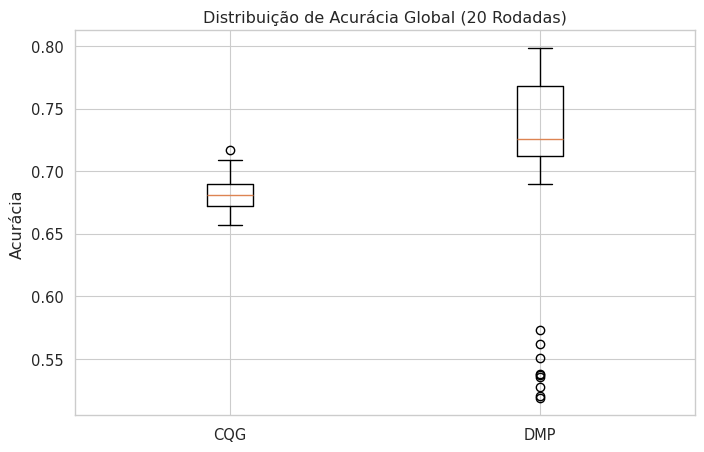

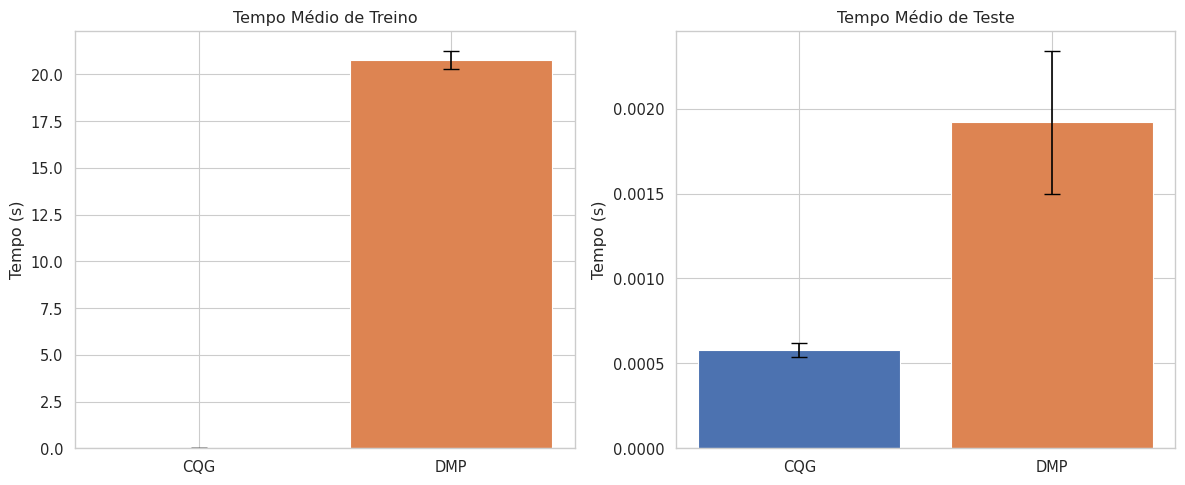

In [8]:
# Consolidação
df_q1 = pd.DataFrame([res_cqg, res_dmp])

print("\n--- Tabela de Resultados (Questão 1.3) ---")
tabela_q1 = formatar_tabela_latex(df_q1, classes_nomes)
display(tabela_q1)

# Boxplot para comparação visual da estabilidade
# (evita usar o parâmetro 'labels', que pode não existir dependendo da versão do Matplotlib)
plt.figure(figsize=(8, 5))
plt.boxplot([acc_cqg, acc_dmp])
plt.xticks([1, 2], ['CQG', 'DMP'])
plt.title("Distribuição de Acurácia Global (20 Rodadas)")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()

# Comparação do Tempo de Treino e Teste (com barras de erro = desvio padrão)
# Obs.: para ter std diferente de 0, o dicionário de resultados precisa conter
# 'Time_Train_Std' e 'Time_Test_Std' (fallback para 0 caso não existam).
plt.figure(figsize=(12, 5))

train_means = [res_cqg['Time_Train_Mean'], res_dmp['Time_Train_Mean']]
test_means  = [res_cqg['Time_Test_Mean'],  res_dmp['Time_Test_Mean']]

train_stds = [res_cqg.get('Time_Train_STD', 0.0), res_dmp.get('Time_Train_STD', 0.0)]
test_stds  = [res_cqg.get('Time_Test_STD', 0.0),  res_dmp.get('Time_Test_STD', 0.0)]

plt.subplot(1, 2, 1)
plt.bar(
    ['CQG', 'DMP'],
    train_means,
    yerr=train_stds,
    capsize=6,
    color=['C0', 'C1'],
    ecolor='black',
    linewidth=0.8
)
plt.title("Tempo Médio de Treino")
plt.ylabel("Tempo (s)")
plt.grid(True, axis='y')

plt.subplot(1, 2, 2)
plt.bar(
    ['CQG', 'DMP'],
    test_means,
    yerr=test_stds,
    capsize=6,
    color=['C0', 'C1'],
    ecolor='black',
    linewidth=0.8
)
plt.title("Tempo Médio de Teste")
plt.ylabel("Tempo (s)")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()


  ---



  ## QUESTÃO 2: Aplicação de PCA







  ### 2.1: Analise do Grafico de Variancia Explicada Cumulativa e Individual

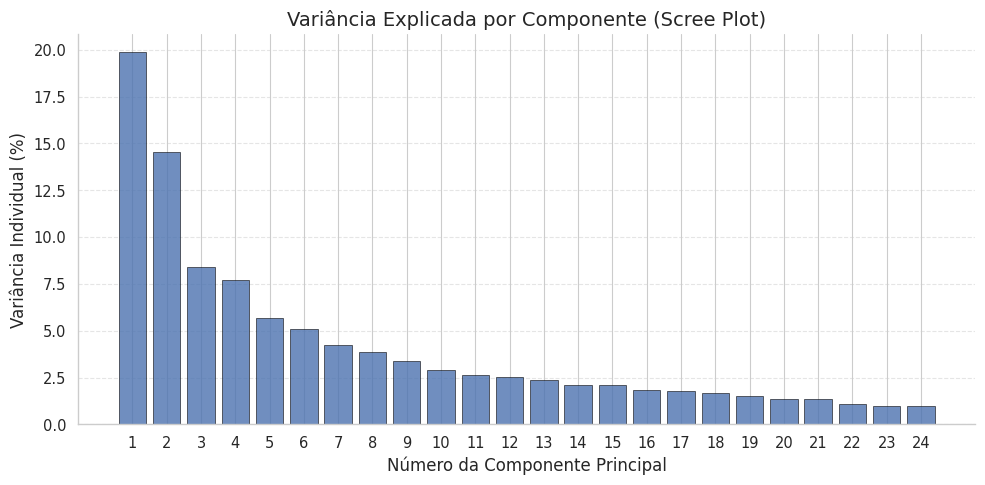

--- Análise de Variância Acumulada ---
Componentes necessários para 50% de variância: q = 4
Componentes necessários para 90% de variância: q = 17
Componentes necessários para 95% de variância: q = 20


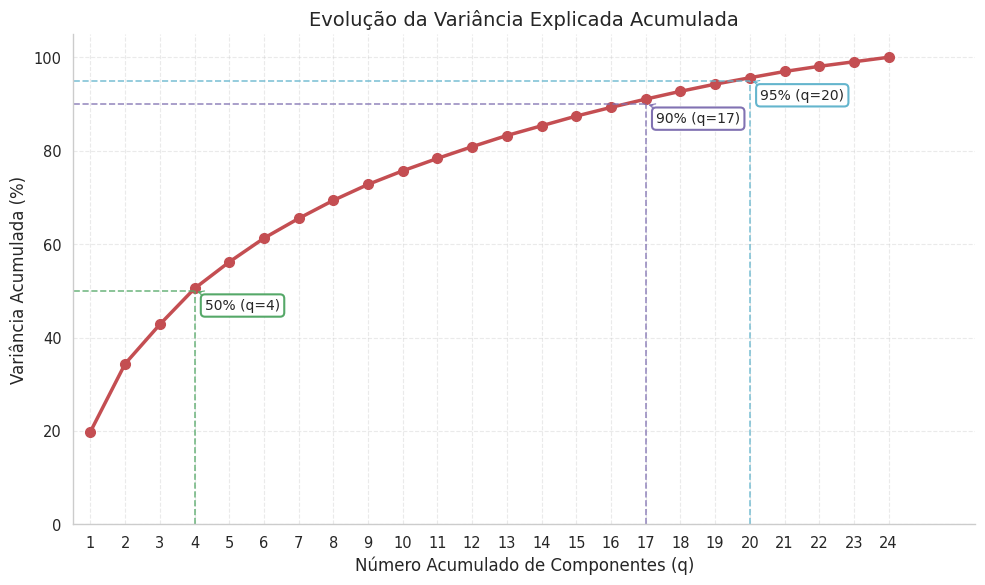

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Ajuste do PCA na base completa (apenas para análise de variância)
pca_full = PCA(n_componentes=None)
pca_full.fit(X_scaled)

# Cálculo das variâncias
var_ratio = pca_full.razao_variancia_explicada_
var_cum = np.cumsum(var_ratio)
componentes = np.arange(1, len(var_ratio) + 1)

# ==========================================
# Gráfico 1: Variância Explicada Individual (Scree Plot)
# ==========================================
plt.figure(figsize=(10, 5))
plt.bar(componentes, var_ratio * 100, color='#4C72B0', alpha=0.8, edgecolor='black', linewidth=0.5)

plt.xlabel('Número da Componente Principal', fontsize=12)
plt.ylabel('Variância Individual (%)', fontsize=12)
plt.title('Variância Explicada por Componente (Scree Plot)', fontsize=14)
plt.xticks(componentes) # Garante que apenas números inteiros apareçam
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Removendo bordas para um visual mais limpo (Tufte style)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ==========================================
# Gráfico 2: Variância Explicada Acumulada
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(componentes, var_cum * 100, marker='o', color='#C44E52', linewidth=2.5, markersize=7)

plt.xlabel('Número Acumulado de Componentes (q)', fontsize=12)
plt.ylabel('Variância Acumulada (%)', fontsize=12)
plt.title('Evolução da Variância Explicada Acumulada', fontsize=14)
plt.xticks(componentes)
plt.grid(axis='both', linestyle='--', alpha=0.4)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Definição dos limiares de interesse e cores para destacá-los
limiares = {0.50: '50%', 0.90: '90%', 0.95: '95%', 0.99: '99%'}
cores_linhas = ['#55A868', '#8172B2', '#64B5CD']

print("--- Análise de Variância Acumulada ---")
for (threshold, label), color in zip(limiares.items(), cores_linhas):
    # Identifica a componente onde a variância atinge ou supera o limite
    q_idx = np.argmax(var_cum >= threshold) + 1
    
    # Linha horizontal da origem até o ponto
    plt.hlines(y=threshold * 100, xmin=0, xmax=q_idx, color=color, linestyle='--', alpha=0.8)
    # Linha vertical do ponto até o eixo X
    plt.vlines(x=q_idx, ymin=0, ymax=threshold * 100, color=color, linestyle='--', alpha=0.8)
    
    # Adicionando uma "caixa de texto" para o rótulo ficar legível mesmo passando sobre a linha
    plt.annotate(f'{label} (q={q_idx})', 
                 xy=(q_idx, threshold * 100), 
                 xytext=(q_idx + 0.3, threshold * 100 - 4),
                 fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, lw=1.5),
                 arrowprops=dict(arrowstyle="->", color=color))
                 
    print(f"Componentes necessários para {threshold * 100:.0f}% de variância: q = {q_idx}")

# Ajustando limites do gráfico para melhorar o respiro das anotações
plt.xlim(0.5, len(var_ratio) + 2.5)
plt.ylim(0, 105)

plt.tight_layout()
plt.show()

Conforme esperado pela análise de condicionamento da matriz de covariância, os dados apresentam baixíssima colinearidade entre as features. Essa característica tem implicações importantes para a aplicação do PCA, não é possível realizar uma redução de dimensionalidade agressiva sem perda significativa de informação, uma vez que cada componente principal contribui substancialmente para a variabilidade total dos dados.

Este comportamento é claramente observado no gráfico de variância explicada. A curva de variância acumulada não atinge um platô, indicando que nenhuma componente individual domina excessivamente a variância dos dados.

Consequentemente, para reter 95% da variância original, é necessário preservar um número elevado de componentes principais, 20 componentes, resultando em uma compressão menos expressiva do que seria observada em datasets com alta redundância entre features.

 ### 2.2 Experimento Comparativo com PCA e Análises de Trade-off

 Nesta etapa, avaliamos empiricamente o impacto do número de componentes (q) na acurácia e no tempo de execução.

Transformação dos dados para `q` dimensões e repetição das 100 rodadas de teste.

Espera-se que o desempenho se mantenha próximo ao original, mas com menor custo computacional no CQG (inversão de matrizes menores) e possivelmente melhor generalização no DMP (remoção de ruído).

Realizando varredura de 'q' para justificação científica (CQG e DMP)...
Aviso: Esta etapa pode demorar alguns minutos devido ao treinamento do DMP.
 -> Avaliando q = 2...
Iniciando 100 rodadas para ClassificadorQuadraticoGaussiano...
Iniciando 100 rodadas para ClassificadorDMP...
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=4, CH=4, Dunn=32, Sil=4, I=5, BH=36] -> Frequências: [k=4(3x), k=32(1x), k=5(1x), k=36(1x)] -> K ótimo: 4
  Classe 1: Votos [DB=4, CH=10, Dunn=36, Sil=4, I=3, BH=36] -> Frequências: [k=4(2x), k=36(2x), k=10(1x), k=3(1x)] -> K ótimo: 4
  Classe 2: Votos [DB=30, CH=36, Dunn=32, Sil=2, I=3, BH=36] -> Frequências: [k=36(2x), k=30(1x), k=32(1x), k=2(1x), k=3(1x)] -> K ótimo: 36
  Classe 3: Votos [DB=3, CH=32, Dunn=36, Sil=2, I=3, BH=36] -> Frequências: [k=3(2x), k=36(2x), k=32(1x), k=2(1x)] -> K ótimo: 3
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=4, CH=4, Dunn=32, Sil=4, I=4, BH=36] -> Frequências: [k=4(4x), k=32(1x

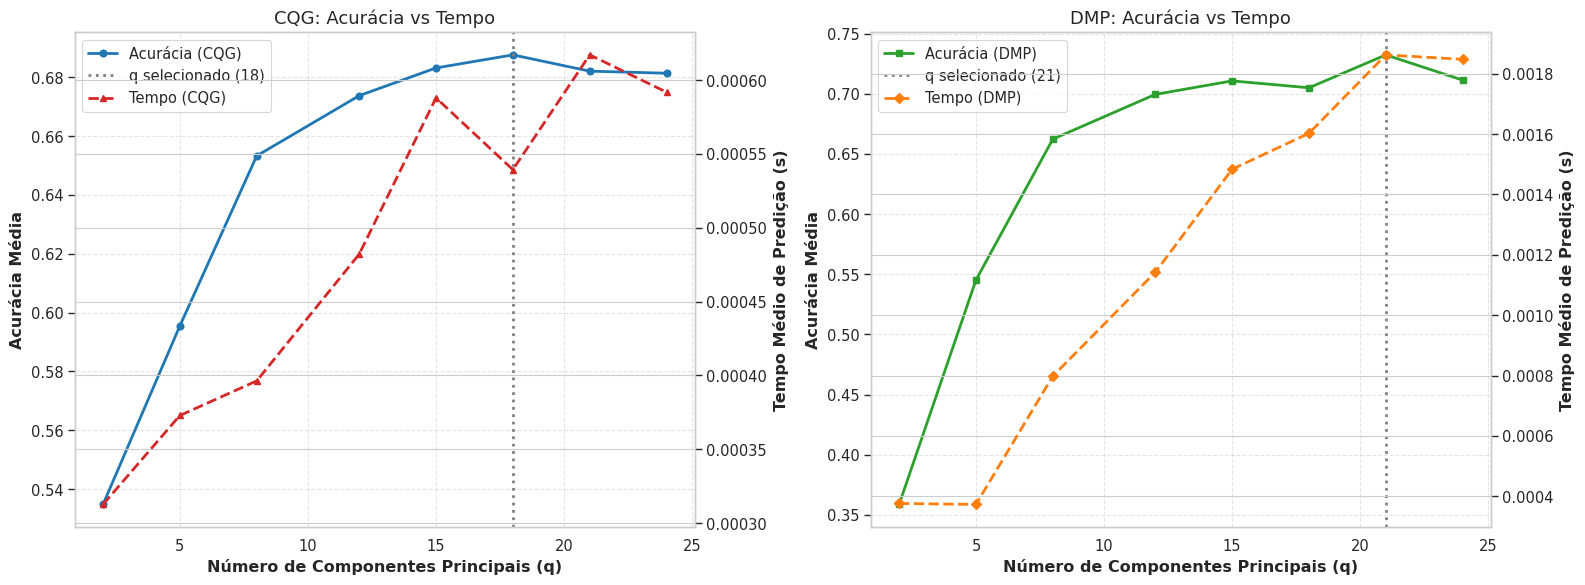

In [10]:
# ==============================================================================
# 1. Análise Empírica: Acurácia vs Custo Computacional para CQG e DMP (Varredura de q)
# ==============================================================================
from sklearn.metrics import confusion_matrix


print("Realizando varredura de 'q' para justificação científica (CQG e DMP)...")
print("Aviso: Esta etapa pode demorar alguns minutos devido ao treinamento do DMP.")

q_test_values = [2, 5, 8, 12, 15, 18, 21, 24]

# Armazenamento de Históricos
acc_cqg_history, time_cqg_history = [], []
acc_dmp_history, time_dmp_history = [], []

# Número reduzido de rodadas APENAS para desenhar a curva em tempo hábil
n_runs_sweep = 100

# Se o DMP estiver demorando muito na varredura, podemos simplificar seus parâmetros
# apenas para esta etapa de descoberta geométrica.
params_dmp_sweep = {'k_min': 2, 'k_max': k_max_heuristic}

for q_test in q_test_values:
    print(f" -> Avaliando q = {q_test}...")

    # Avaliação CQG
    res_cqg_temp, _ = executar_experimento_monte_carlo(
        X_scaled, y_encoded, ClassificadorQuadraticoGaussiano, params_cqg, n_runs=n_runs_sweep, q_pca=q_test
    )
    acc_cqg_history.append(res_cqg_temp['Global_Mean'])
    time_cqg_history.append(res_cqg_temp['Time_Test_Mean'])

    # Avaliação DMP
    res_dmp_temp, _ = executar_experimento_monte_carlo(
        X_scaled, y_encoded, ClassificadorDMP, params_dmp_sweep, n_runs=n_runs_sweep, q_pca=q_test
    )
    acc_dmp_history.append(res_dmp_temp['Global_Mean'])
    time_dmp_history.append(res_dmp_temp['Time_Test_Mean'])

# ==============================================================================
# Plotagem Dupla: Acurácia (Eixo Esquerdo) e Tempo (Eixo Direito)
# ==============================================================================
# Dois gráficos (um por modelo): Acurácia (eixo esquerdo) e Tempo (eixo direito)
q_selected_cqg = q_test_values[np.argmax(acc_cqg_history)]
q_selected_dmp = q_test_values[np.argmax(acc_dmp_history)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# ==============================================================================
# Gráfico 1: CQG
# ==============================================================================
ax1 = axes[0]
ax1.set_title("CQG: Acurácia vs Tempo", fontsize=13)
ax1.set_xlabel("Número de Componentes Principais (q)", fontweight="bold")
ax1.set_ylabel("Acurácia Média", fontweight="bold")
ax1.plot(q_test_values, acc_cqg_history, marker="o", color="#1f77b4", linewidth=2, label="Acurácia (CQG)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.axvline(x=q_selected_cqg, color="gray", linestyle=":", linewidth=2, label=f"q selecionado ({q_selected_cqg})")

ax1b = ax1.twinx()
ax1b.set_ylabel("Tempo Médio de Predição (s)", fontweight="bold")
ax1b.plot(q_test_values, time_cqg_history, marker="^", linestyle="--", color="#d62728", linewidth=2, label="Tempo (CQG)")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="best")

# ==============================================================================
# Gráfico 2: DMP
# ==============================================================================
ax2 = axes[1]
ax2.set_title("DMP: Acurácia vs Tempo", fontsize=13)
ax2.set_xlabel("Número de Componentes Principais (q)", fontweight="bold")
ax2.set_ylabel("Acurácia Média", fontweight="bold")
ax2.plot(q_test_values, acc_dmp_history, marker="s", color="#2ca02c", linewidth=2, label="Acurácia (DMP)")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.axvline(x=q_selected_dmp, color="gray", linestyle=":", linewidth=2, label=f"q selecionado ({q_selected_dmp})")

ax2b = ax2.twinx()
ax2b.set_ylabel("Tempo Médio de Predição (s)", fontweight="bold")
ax2b.plot(q_test_values, time_dmp_history, marker="D", linestyle="--", color="#ff7f0e", linewidth=2, label="Tempo (DMP)")

lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="best")

plt.tight_layout()
plt.show()


Transformação Oficial: (5456, 24) -> (5456, 18)
Iniciando 100 rodadas para ClassificadorQuadraticoGaussiano...
Iniciando 100 rodadas para ClassificadorDMP...
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=25, CH=8, Dunn=2, Sil=34, I=3, BH=36] -> Frequências: [k=25(1x), k=8(1x), k=2(1x), k=34(1x), k=3(1x), k=36(1x)] -> K ótimo: 25
  Classe 1: Votos [DB=35, CH=2, Dunn=9, Sil=35, I=3, BH=36] -> Frequências: [k=35(2x), k=2(1x), k=9(1x), k=3(1x), k=36(1x)] -> K ótimo: 35
  Classe 2: Votos [DB=36, CH=2, Dunn=36, Sil=36, I=2, BH=36] -> Frequências: [k=36(4x), k=2(2x)] -> K ótimo: 36
  Classe 3: Votos [DB=29, CH=2, Dunn=16, Sil=29, I=2, BH=36] -> Frequências: [k=29(2x), k=2(2x), k=16(1x), k=36(1x)] -> K ótimo: 29
Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=36, CH=8, Dunn=11, Sil=36, I=2, BH=36] -> Frequências: [k=36(3x), k=8(1x), k=11(1x), k=2(1x)] -> K ótimo: 36
  Classe 1: Votos [DB=36, CH=2, Dunn=3, Sil=36, I=3, BH=36] -> Frequências: [k

,Classificador,Global,Move-Forward,Sharp-Right-Turn,Slight-Left-Turn,Slight-Right-Turn
0,ClassificadorQuadraticoGaussiano (PCA),0.6776 ± 0.0114,0.5765 ± 0.0172,0.6774 ± 0.0194,0.8626 ± 0.0355,0.8750 ± 0.0252
1,ClassificadorDMP (PCA),0.6386 ± 0.1016,0.6692 ± 0.2384,0.5475 ± 0.2999,0.7967 ± 0.2109,0.7222 ± 0.2947


Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=35, CH=2, Dunn=35, Sil=35, I=2, BH=36] -> Frequências: [k=35(3x), k=2(2x), k=36(1x)] -> K ótimo: 35
  Classe 1: Votos [DB=29, CH=2, Dunn=35, Sil=34, I=3, BH=36] -> Frequências: [k=29(1x), k=2(1x), k=35(1x), k=34(1x), k=3(1x), k=36(1x)] -> K ótimo: 29
  Classe 2: Votos [DB=36, CH=2, Dunn=15, Sil=35, I=2, BH=36] -> Frequências: [k=36(2x), k=2(2x), k=15(1x), k=35(1x)] -> K ótimo: 36
  Classe 3: Votos [DB=33, CH=4, Dunn=19, Sil=33, I=2, BH=36] -> Frequências: [k=33(2x), k=4(1x), k=19(1x), k=2(1x), k=36(1x)] -> K ótimo: 33


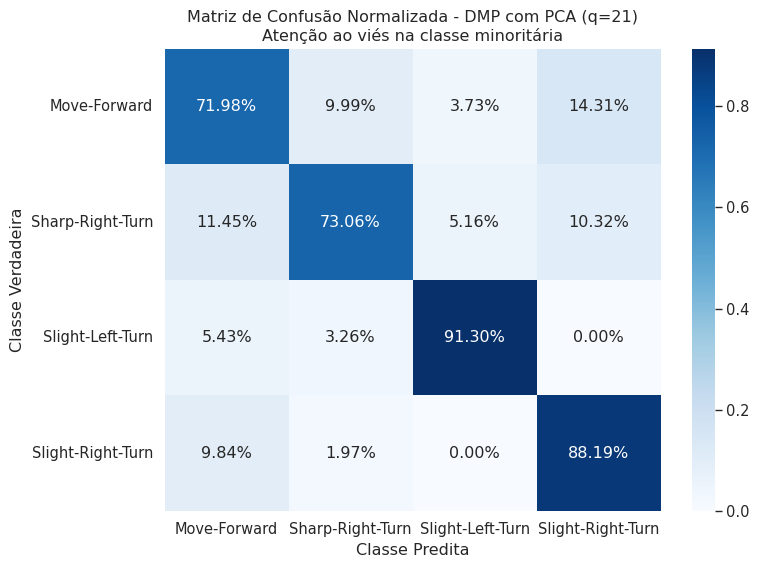

In [11]:

# ==============================================================================
# 2. Execução Oficial no Espaço Reduzido (q selecionado)
# ==============================================================================
pca_final_cqg = PCA(n_componentes=q_selected_cqg)
pca_final_cqg.fit(X_scaled)
X_pca_cqg = pca_final_cqg.transform(X_scaled)

print(f"\nTransformação Oficial: {X_scaled.shape} -> {X_pca_cqg.shape}")

# Execução do Experimento no Espaço Reduzido (20 rodadas para rigor estatístico)
res_cqg_pca, acc_cqg_pca = executar_experimento_monte_carlo(X_pca_cqg, y_encoded, ClassificadorQuadraticoGaussiano, params_cqg, n_runs=100)


pca_final_dmp = PCA(n_componentes=q_selected_dmp)
pca_final_dmp.fit(X_scaled)
X_pca_dmp = pca_final_dmp.transform(X_scaled)
res_dmp_pca, acc_dmp_pca = executar_experimento_monte_carlo(X_pca_dmp, y_encoded, ClassificadorDMP, params_dmp, n_runs=100)
# Consolidação da Tabela
df_q2 = pd.DataFrame([res_cqg_pca, res_dmp_pca])
df_q2['Modelo'] = df_q2['Modelo'] + " (PCA)"

print("\n--- Tabela de Resultados (Questão 2.2 - Com PCA) ---")
tabela_q2 = formatar_tabela_latex(df_q2, classes_nomes)
display(tabela_q2)

# ==============================================================================
# 3. Análise de Desbalanceamento (Matriz de Confusão Normalizada)
# ==============================================================================
# Vamos fazer um split único para gerar a matriz de confusão visual do DMP com PCA
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_dmp, y_encoded, test_size=0.3, random_state=42)

dmp_viz = ClassificadorDMP(**params_dmp)
dmp_viz.fit(X_train_pca, y_train_pca)
y_pred_viz = dmp_viz.predict(X_test_pca)

cm = confusion_matrix(y_test_pca, y_pred_viz, normalize='true') # Normalizado por linha (Recall)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_nomes, yticklabels=classes_nomes)
plt.title(f"Matriz de Confusão Normalizada - DMP com PCA (q={q_selected_dmp})\nAtenção ao viés na classe minoritária")
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita')
plt.show()


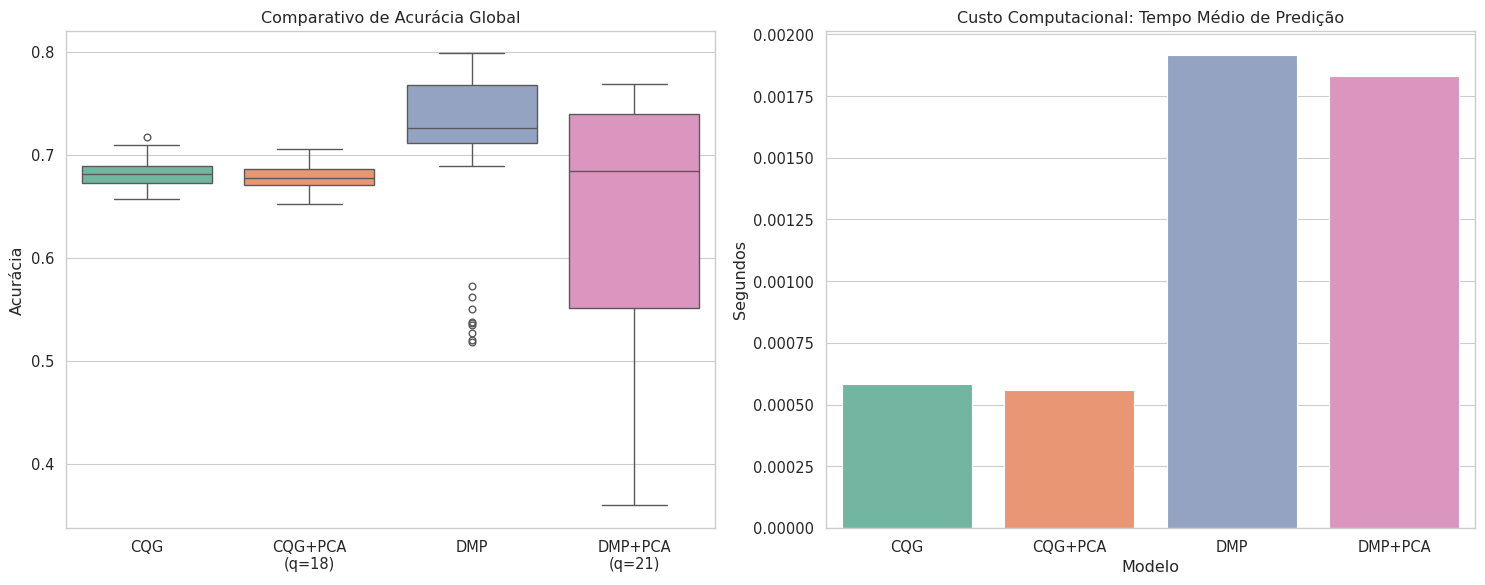


--- Estrutura Topológica do DMP (Distribuição de Protótipos) ---
Slight-Left-Turn     36
Move-Forward         35
Slight-Right-Turn    33
Sharp-Right-Turn     29
Name: count, dtype: int64

Comentário: Observe como o número de protótipos se correlaciona com o número de amostras da classe.
Classes maiores exigem partições de Voronoi mais complexas.


In [12]:

# ==============================================================================
# 4. Boxplots Comparativos (Acurácia e Tempo)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot 1: Acurácia
data_boxplot_acc = [acc_cqg, acc_cqg_pca, acc_dmp, acc_dmp_pca]
labels_boxplot = ['CQG', f'CQG+PCA\n(q={q_selected_cqg})', 'DMP', f'DMP+PCA\n(q={q_selected_dmp})']
sns.boxplot(data=data_boxplot_acc, ax=axes[0], palette='Set2')
axes[0].set_xticklabels(labels_boxplot)
axes[0].set_title("Comparativo de Acurácia Global")
axes[0].set_ylabel("Acurácia")

# Boxplot 2: Tempos de Treino/Teste baseados no histórico
# Extraindo os tempos diretamente do Dicionário de resultados para mostrar a diferença
tempos_execucao = pd.DataFrame({
    'Modelo': ['CQG', 'CQG+PCA', 'DMP', 'DMP+PCA'],
    'Tempo Teste (s)': [res_cqg['Time_Test_Mean'], res_cqg_pca['Time_Test_Mean'], 
                        res_dmp['Time_Test_Mean'], res_dmp_pca['Time_Test_Mean']]
})

sns.barplot(data=tempos_execucao, x='Modelo', y='Tempo Teste (s)', ax=axes[1], palette='Set2')
axes[1].set_title("Custo Computacional: Tempo Médio de Predição")
axes[1].set_ylabel("Segundos")

plt.tight_layout()
plt.show()

# ==============================================================================
# 5. Reflexão sobre a Topologia do DMP
# ==============================================================================
# Analisando quantos protótipos foram alocados para cada classe
contagem_prototipos = pd.Series(dmp_viz.labels_).map(dict(enumerate(classes_nomes))).value_counts()
print("\n--- Estrutura Topológica do DMP (Distribuição de Protótipos) ---")
print(contagem_prototipos)
print("\nComentário: Observe como o número de protótipos se correlaciona com o número de amostras da classe.")
print("Classes maiores exigem partições de Voronoi mais complexas.")


  ### Visualização Extra: Superfícies de Decisão (2D)



  Para fins didáticos, projetamos os dados nas 2 primeiras componentes principais e treinamos os modelos **apenas nestas 2 dimensões** para visualizar as regiões de decisão.



  *Nota: A performance aqui será inferior à de 24D ou qD, pois estamos usando apenas 2 dimensões.*

Treinando DMP Multi-Protótipo. Classes: [0 1 2 3]
  Classe 0: Votos [DB=4, CH=5, Dunn=3, Sil=3, I=3, BH=15] -> Frequências: [k=3(3x), k=4(1x), k=5(1x), k=15(1x)] -> K ótimo: 3
  Classe 1: Votos [DB=4, CH=15, Dunn=14, Sil=3, I=3, BH=15] -> Frequências: [k=15(2x), k=3(2x), k=4(1x), k=14(1x)] -> K ótimo: 15
  Classe 2: Votos [DB=6, CH=13, Dunn=10, Sil=2, I=5, BH=15] -> Frequências: [k=6(1x), k=13(1x), k=10(1x), k=2(1x), k=5(1x), k=15(1x)] -> K ótimo: 6
  Classe 3: Votos [DB=4, CH=13, Dunn=13, Sil=4, I=4, BH=15] -> Frequências: [k=4(3x), k=13(2x), k=15(1x)] -> K ótimo: 4


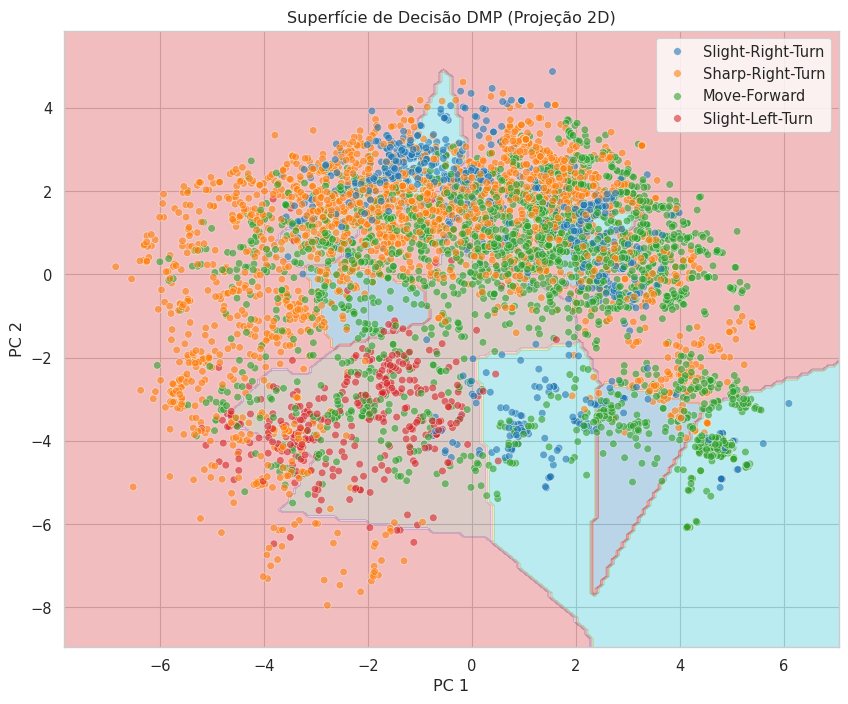

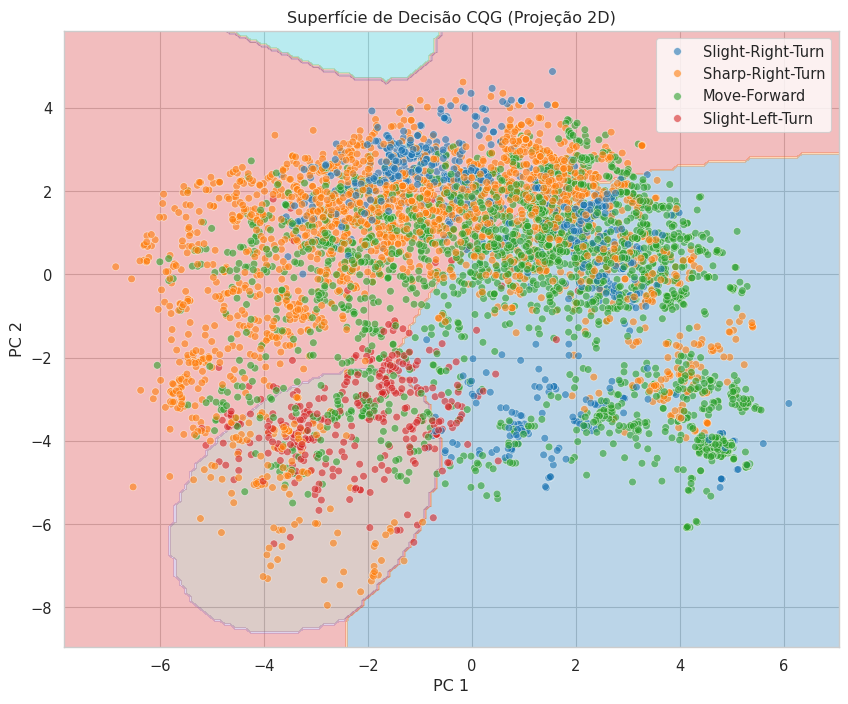

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from classificao_padroes.models_trabalho3 import PCA

def plot_decision_boundary(X, y, model, title, le):
    # Treina modelo em 2D
    model.fit(X, y)

    # Meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predição no Grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    
    # Atualizado para as versões mais recentes do Matplotlib
    try:
        cmap = plt.cm.get_cmap('tab10')
    except AttributeError:
        import matplotlib as mpl
        cmap = mpl.colormaps['tab10']

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    y_class_names = le.inverse_transform(y)
    
    # Passamos 'y_class_names' para o hue em vez de 'y'
    sns.scatterplot(
        x=X[:, 0], 
        y=X[:, 1], 
        hue=y_class_names, 
        palette='tab10', 
        legend='full', 
        s=30, 
        alpha=0.6
    )

    # Se for DMP, plotar protótipos
    if hasattr(model, 'all_prototypes_') and len(model.all_prototypes_) > 0:
        prototypes = model.all_prototypes_
        prototype_labels = model.all_labels_
        
        # Prevenindo erro de divisão por zero caso haja apenas a classe 0
        max_label = np.max(prototype_labels) if np.max(prototype_labels) > 0 else 1
        colors = cmap(prototype_labels / max_label)
        
        plt.scatter(prototypes[:, 0], prototypes[:, 1], 
                    c=colors, marker='X', s=100, label='Protótipos', edgecolors='white', linewidths=2)

    plt.title(title)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.legend()
    plt.show()

# --- Execução ---

# Preparação 2D
pca_2d = PCA(n_componentes=2)
pca_2d.fit(X_scaled)
X_2d = pca_2d.transform(X_scaled)


# Visualização DMP 2D (Adicionando o argumento le=le)
dmp_2d = ClassificadorDMP(k_min=2, k_max=15, n_runs=50)
plot_decision_boundary(X_2d, y_encoded, dmp_2d, "Superfície de Decisão DMP (Projeção 2D)", le=le)

# Visualização CQG 2D (Adicionando o argumento le=le)
cqg_2d = ClassificadorQuadraticoGaussiano()
plot_decision_boundary(X_2d, y_encoded, cqg_2d, "Superfície de Decisão CQG (Projeção 2D)", le=le)
